# ML2 Assignment #3, Task 2: Classified Sequence Data

**Janin Jankovski, Florian Robrecht, Anna Hartmann**

---

> *NASA's deep-space probe Sentinel IX has returned a corrupted, biologically-rich data dump.
> A leaked CSV holds DNA-like sequences of unknown origin. Scientists suspect more than one
> biological source; rumours hint at non-Euclidean comparisons (Hamming, k-mer based).
> Our task is to recover the hidden structure.*

We treat the labels as **unknown** and frame the problem as **unsupervised structure discovery**:
clustering plus an outlier-based forensic layer that flags sequences which look least like their
neighbours.

**Roadmap**

1. Robust loader and exploratory analysis
2. Two complementary sequence representations: *normalized Hamming distance* (positional) and
   *k-mer Jaccard distance* (compositional, alignment-free)
3. Distance-matrix visualization
4. Hierarchical clustering with silhouette-based cluster-count selection on both metrics
5. Low-dimensional embeddings (MDS, t-SNE)
6. Three-detector forensic layer for suspicious sequences
7. Representative sequences per cluster
8. Reflection on metric choice and a measured conclusion


## 1. Setup

In [1]:
# load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import product

from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

from sklearn.manifold import MDS, TSNE
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.ensemble import IsolationForest

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

DATA_PATH = "data/highly_classified_data.csv"


## 2. Robust loader and exploratory analysis

The file is semicolon-delimited with a trailing `;` after the sequence column, which
produces an empty unnamed column on read; we drop it. We then validate the alphabet,
sequence lengths, and missingness, and compute per-sequence base statistics.

In [2]:
def load_sequences(path):
    df = pd.read_csv(path, sep=";")
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
    df["Sequence"] = df["Sequence"].astype(str).str.strip().str.upper()
    df["ID"] = df["ID"].astype(str).str.strip()
    assert df["Sequence"].notna().all(), "missing sequences detected"
    return df.reset_index(drop=True)

df = load_sequences(DATA_PATH)
df["length"] = df["Sequence"].str.len()

alphabet = set("".join(df["Sequence"]))
all_same_len = df["length"].nunique() == 1
print(f"{len(df)} sequences | length {df['length'].min()}..{df['length'].max()} "
      f"(uniform: {all_same_len}) | alphabet {sorted(alphabet)} | "
      f"missing: {df.isna().sum().sum()}")
display(df.head())


100 sequences | length 10000..10000 (uniform: True) | alphabet ['A', 'C', 'G', 'T'] | missing: 0


,ID,Sequence,length
0,seq1,CAAACTTATTCGACGATTGACTTAATCTTAATGATATCGAAGGTTA...,10000
1,seq2,CAAACTTATTAGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,10000
2,seq3,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,10000
3,seq4,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,10000
4,seq5,CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAA...,10000


In [3]:
# per-sequence base composition
bases = list("ACGT")
counts = pd.DataFrame(
    [Counter(s) for s in df["Sequence"]],
    index=df["ID"],
).reindex(columns=bases).fillna(0).astype(int)

freq = counts.div(counts.sum(axis=1), axis=0)
freq.columns = [f"freq_{b}" for b in bases]
df_eda = pd.concat([df[["ID", "length"]], counts, freq], axis=1)
df_eda["GC"] = freq["freq_G"] + freq["freq_C"]

display(df_eda.describe().round(4))


,length,A,C,G,T,freq_A,freq_C,freq_G,freq_T,GC
count,100.0,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000,100.0000
mean,10000.0,2502.7300,2487.1700,2511.3100,2498.7900,0.2503,0.2487,0.2511,0.2499,0.4998
std,0.0,17.3676,43.6763,47.1307,67.2194,0.0017,0.0044,0.0047,0.0067,0.0065
min,10000.0,2446.0000,2407.0000,2447.0000,2358.0000,0.2446,0.2407,0.2447,0.2358,0.4926
25%,10000.0,2492.0000,2454.7500,2467.5000,2479.5000,0.2492,0.2455,0.2468,0.2480,0.4952
50%,10000.0,2503.0000,2492.0000,2498.0000,2531.0000,0.2503,0.2492,0.2498,0.2531,0.4973
75%,10000.0,2514.5000,2523.0000,2553.2500,2543.0000,0.2514,0.2523,0.2553,0.2543,0.5024
max,10000.0,2540.0000,2562.0000,2611.0000,2584.0000,0.2540,0.2562,0.2611,0.2584,0.5143


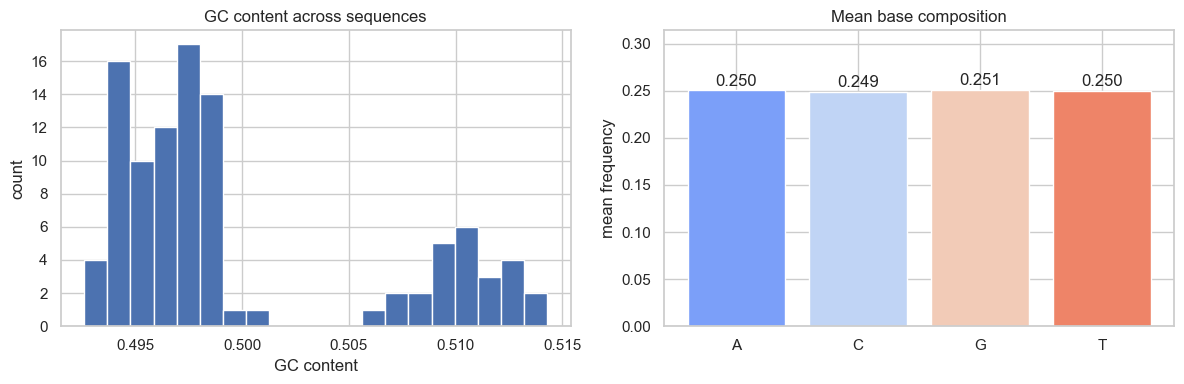

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_eda["GC"], bins=20, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("GC content")
axes[0].set_ylabel("count")
axes[0].set_title("GC content across sequences")

mean_freq = freq.mean()
axes[1].bar(bases, mean_freq.values, color=sns.color_palette("coolwarm", 4))
axes[1].set_ylabel("mean frequency")
axes[1].set_ylim(0, max(mean_freq.values) * 1.25)
axes[1].set_title("Mean base composition")
for i, v in enumerate(mean_freq.values):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()


The GC histogram and mean composition show that aggregate base statistics are nearly
uniform — any structure must come from **positional** or **motif-level** information, not
from coarse composition alone. This motivates the next section.

## 3. Two sequence representations

### 3.1 Normalized Hamming distance (positional)

For two sequences of equal length \(L\), the normalized Hamming distance is the fraction of
positions where they differ:

$$d_H(x, y) = \frac{1}{L}\sum_{i=1}^{L} \mathbb{1}[x_i \neq y_i].$$

It is the principled positional metric on fixed-length DNA (one-hot Euclidean reduces to
the same quantity up to a constant factor). It captures point mutations and lineage drift
but ignores indels and motif shifts — acceptable here because all sequences share the same
length of 10,000 bp.

In [5]:
# encode sequences as a (n, L) uint8 matrix
seq_arr = np.stack([
    np.frombuffer(s.encode("ascii"), dtype=np.uint8)
    for s in df["Sequence"]
])
n, L = seq_arr.shape

D_ham = np.zeros((n, n), dtype=np.float64)
for i in range(n):
    D_ham[i, i + 1:] = (seq_arr[i + 1:] != seq_arr[i]).mean(axis=1)
D_ham = D_ham + D_ham.T

print(f"D_ham shape={D_ham.shape}, range=[{D_ham.min():.4f}, {D_ham.max():.4f}], "
      f"symmetric={np.allclose(D_ham, D_ham.T)}, zero diag={np.allclose(np.diag(D_ham), 0)}")


D_ham shape=(100, 100), range=[0.0000, 0.7597], symmetric=True, zero diag=True


### 3.2 k-mer Jaccard distance (compositional, alignment-free)

We slide a window of length \(k=7\) across each sequence and record which of the
\(4^7 = 16{,}384\) possible k-mers appear. The Jaccard distance between two presence sets is

$$d_J(A, B) = 1 - \frac{|A \cap B|}{|A \cup B|}.$$

We pick \(k=7\) because at our sequence length \(L=10{,}000\) it gives roughly
\(\sim 46\%\) presence saturation per sequence — informative without being either
sparse-noisy (large \(k\)) or saturated-to-uniform (small \(k\)). The metric is
alignment-free and captures motif content. It misses positional ordering and the exact
abundance of each k-mer — complementary blind spots to Hamming.

In [6]:
K_VAL = 7
kmers = ["".join(p) for p in product("ACGT", repeat=K_VAL)]
kmer_index = {km: i for i, km in enumerate(kmers)}
n_kmers = len(kmers)

K_count = np.zeros((n, n_kmers), dtype=np.int32)
for row, s in enumerate(df["Sequence"]):
    for i in range(L - K_VAL + 1):
        K_count[row, kmer_index[s[i:i + K_VAL]]] += 1

print(f"k-mer presence saturation: "
      f"{(K_count > 0).mean():.1%} of {n_kmers} possible k-mers per sequence (mean)")

K_presence = (K_count > 0).astype(np.uint8)
K_freq = K_count / (L - K_VAL + 1)

D_jac = squareform(pdist(K_presence, metric="jaccard"))
print(f"K_count shape={K_count.shape} (sequences x k-mers)")
print(f"D_jac shape={D_jac.shape}, range=[{D_jac.min():.4f}, {D_jac.max():.4f}]")


k-mer presence saturation: 45.6% of 16384 possible k-mers per sequence (mean)
K_count shape=(100, 16384) (sequences x k-mers)
D_jac shape=(100, 100), range=[0.0000, 0.7195]


## 4. Distance-matrix visualization

We first inspect both raw distance matrices, then a clustermap on Hamming to preview block
structure under a hierarchical reordering.

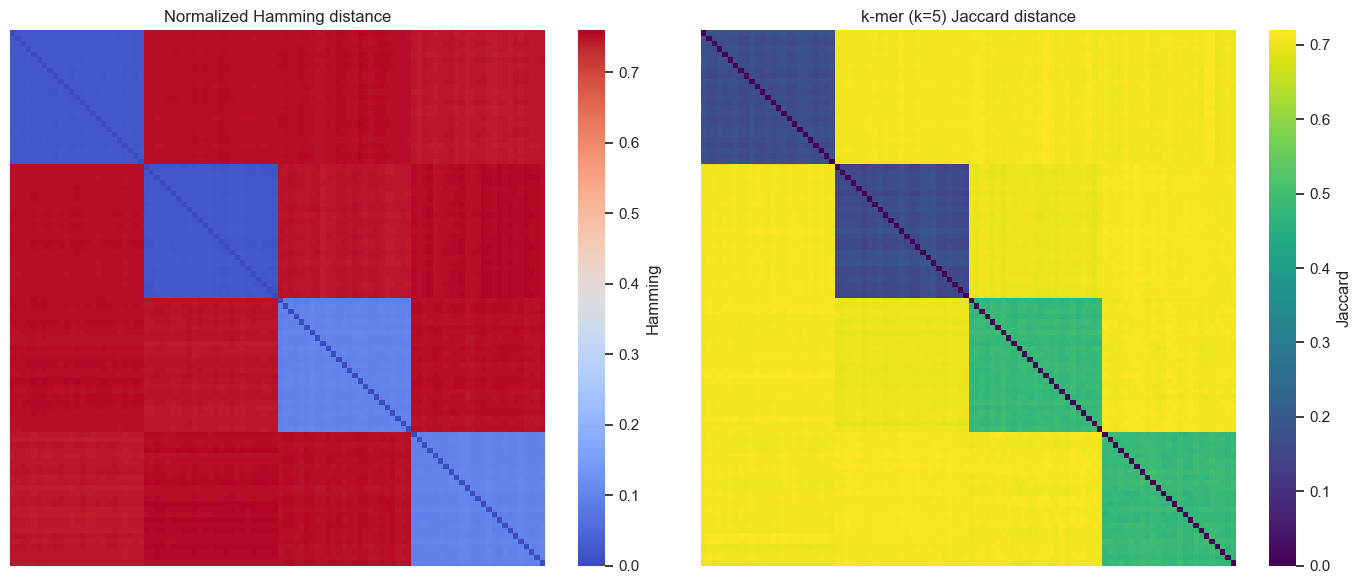

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(D_ham, cmap="coolwarm", ax=axes[0], cbar_kws={"label": "Hamming"})
axes[0].set_title("Normalized Hamming distance")
sns.heatmap(D_jac, cmap="viridis", ax=axes[1], cbar_kws={"label": "Jaccard"})
axes[1].set_title("k-mer (k=5) Jaccard distance")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


/Users/florianrobrecht/Documents/006_GitHub/Machine-Learning-2/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/florianrobrecht/Documents/006_GitHub/Machine-Learning-2/.venv/lib/python3.13/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/Users/florianrobrecht/Documents/006_GitHub/Machine-Learning-2/.venv/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/florianrobrecht/Documents/006_GitHub/Machine-Learning-2/.venv/lib/python3.13/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspici

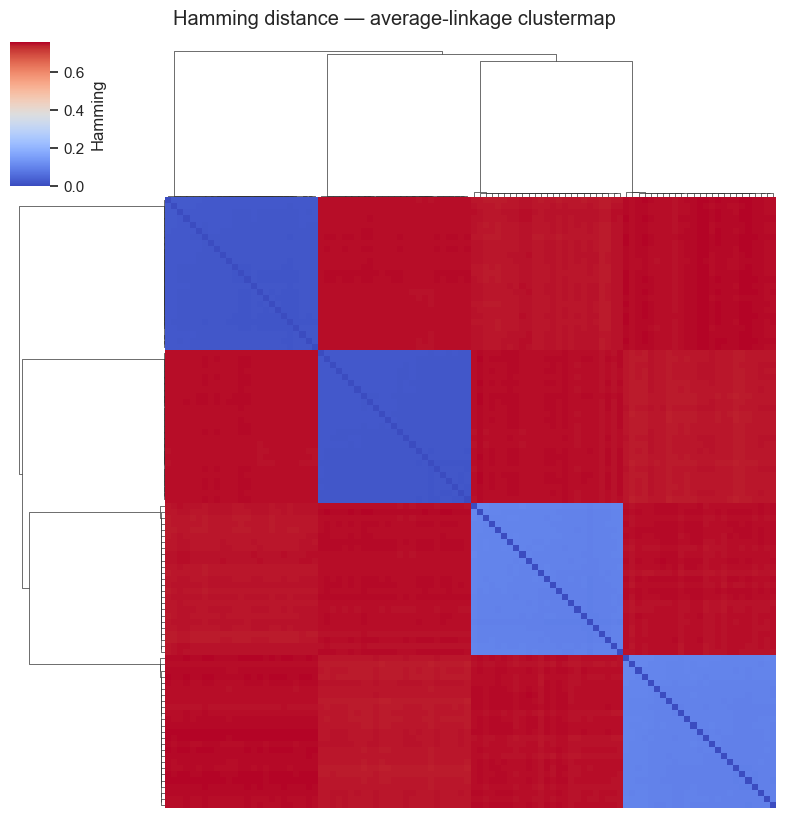

In [8]:
g = sns.clustermap(
    D_ham,
    method="average",
    cmap="coolwarm",
    figsize=(8, 8),
    cbar_kws={"label": "Hamming"},
    xticklabels=False,
    yticklabels=False,
)
g.figure.suptitle("Hamming distance — average-linkage clustermap", y=1.02)
plt.show()


The clustermap exposes a clear block-diagonal pattern after reordering: the dataset is
**not homogeneous**. The next step is to choose how many blocks the data actually supports.

## 5. Hierarchical clustering and cluster-count selection

We use **agglomerative clustering with average linkage (UPGMA)**, the standard choice in
sequence biology when working from a precomputed distance:

- Ward linkage requires Euclidean inputs, undefined here.
- Single linkage chains noisy DNA into spurious super-clusters.
- Average linkage balances both and accepts arbitrary metrics.

We fit it on each distance matrix separately, then choose the cluster count by sweeping
\(k\in\{2,\dots,8\}\) and picking the silhouette peak that **agrees across both
metrics** — agreement across two independent representations is our headline confidence
signal.

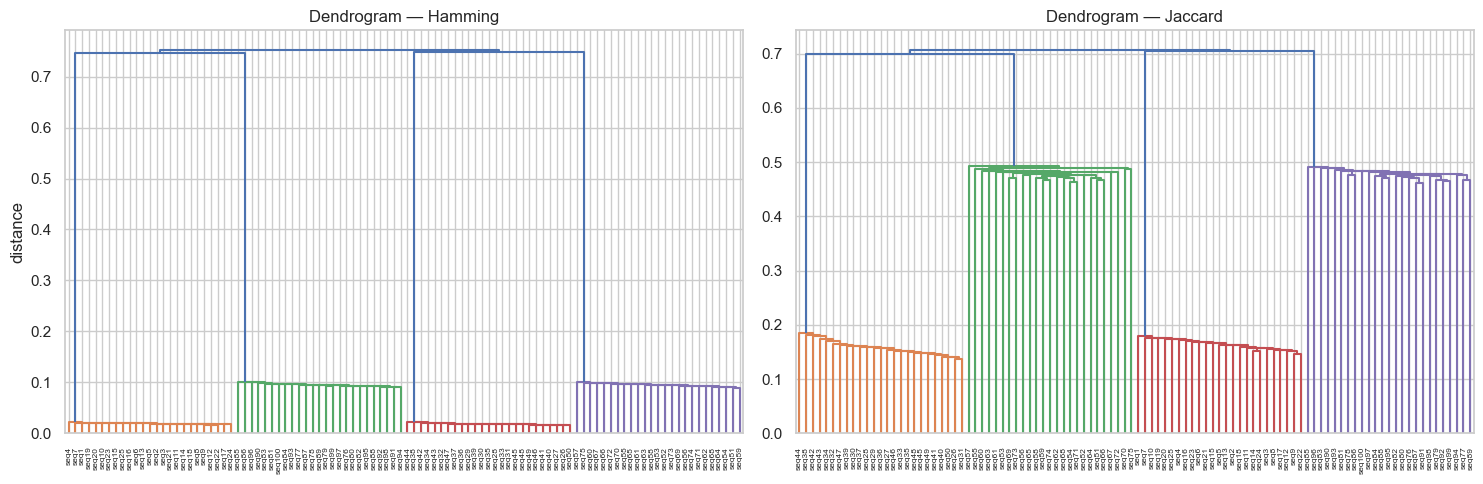

In [9]:
Z_ham = linkage(squareform(D_ham, checks=False), method="average")
Z_jac = linkage(squareform(D_jac, checks=False), method="average")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
dendrogram(Z_ham, ax=axes[0], color_threshold=0.7 * Z_ham[:, 2].max(),
           labels=df["ID"].values, leaf_font_size=6)
axes[0].set_title("Dendrogram — Hamming")
axes[0].set_ylabel("distance")
dendrogram(Z_jac, ax=axes[1], color_threshold=0.7 * Z_jac[:, 2].max(),
           labels=df["ID"].values, leaf_font_size=6)
axes[1].set_title("Dendrogram — Jaccard")
for ax in axes:
    ax.tick_params(axis="x", labelrotation=90)
plt.tight_layout()
plt.show()


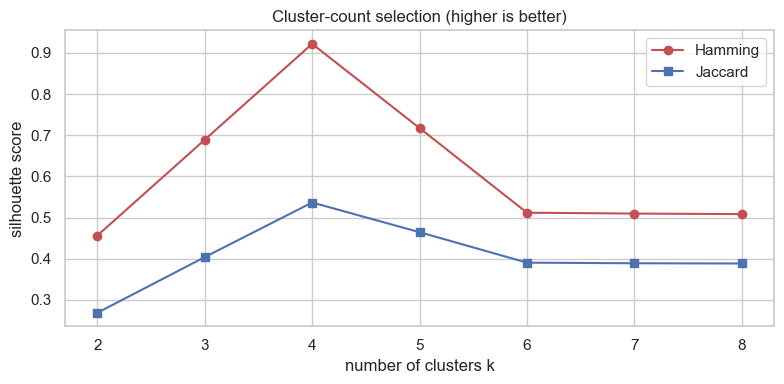

Silhouette peak — Hamming: k=4 (score=0.922) | Jaccard: k=4 (score=0.537)


In [10]:
ks = range(2, 9)
sil_ham = []
sil_jac = []
for k in ks:
    lab_h = fcluster(Z_ham, k, criterion="maxclust")
    lab_j = fcluster(Z_jac, k, criterion="maxclust")
    sil_ham.append(silhouette_score(D_ham, lab_h, metric="precomputed")
                   if len(set(lab_h)) > 1 else np.nan)
    sil_jac.append(silhouette_score(D_jac, lab_j, metric="precomputed")
                   if len(set(lab_j)) > 1 else np.nan)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(ks), sil_ham, "o-", label="Hamming", color="#C44E52")
ax.plot(list(ks), sil_jac, "s-", label="Jaccard", color="#4C72B0")
ax.set_xlabel("number of clusters k")
ax.set_ylabel("silhouette score")
ax.set_title("Cluster-count selection (higher is better)")
ax.legend()
plt.tight_layout()
plt.show()

k_star = int(list(ks)[int(np.nanargmax(sil_ham))])
k_star_jac = int(list(ks)[int(np.nanargmax(sil_jac))])
print(f"Silhouette peak — Hamming: k={k_star} (score={max(sil_ham):.3f}) | "
      f"Jaccard: k={k_star_jac} (score={max(sil_jac):.3f})")


In [11]:
# adopt the Hamming peak; if both metrics agree, confidence is high
clusters_ham = fcluster(Z_ham, k_star, criterion="maxclust")
clusters_jac = fcluster(Z_jac, k_star, criterion="maxclust")

ct = pd.crosstab(
    pd.Series(clusters_ham, name="Hamming cluster"),
    pd.Series(clusters_jac, name="Jaccard cluster"),
)
print(f"k* = {k_star}  (Hamming peak; Jaccard peak was at k={k_star_jac})")
display(ct)


k* = 4  (Hamming peak; Jaccard peak was at k=4)


Jaccard cluster,1,2,3,4
Hamming cluster,,,,
1,0,0,25,0
2,0,0,0,25
3,25,0,0,0
4,0,25,0,0


A near-block-diagonal contingency table means the two representations recover essentially
the same partition — strong cross-metric corroboration of the cluster count.

## 6. Low-dimensional embeddings

Two views of the same partition: **MDS** preserves Hamming distances directly; **t-SNE** on
k-mer frequencies emphasises local neighbourhood structure in a different feature space. If
both show the same coloured blocks, the structure is real.

/Users/florianrobrecht/Documents/006_GitHub/Machine-Learning-2/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


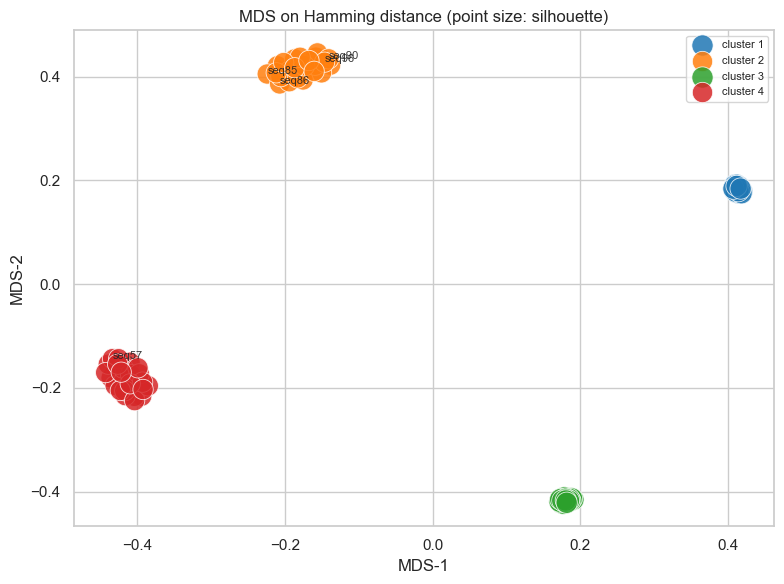

In [12]:
mds = MDS(n_components=2, dissimilarity="precomputed",
          random_state=42, n_init=4, normalized_stress="auto", init="random")
emb_mds = mds.fit_transform(D_ham)

sil_per = silhouette_samples(D_ham, clusters_ham, metric="precomputed")

palette = sns.color_palette("tab10", n_colors=k_star)
fig, ax = plt.subplots(figsize=(8, 6))
for c in np.unique(clusters_ham):
    mask = clusters_ham == c
    ax.scatter(emb_mds[mask, 0], emb_mds[mask, 1],
               s=40 + 200 * np.clip(sil_per[mask], 0, None),
               color=palette[c - 1], label=f"cluster {c}",
               edgecolor="white", linewidth=0.6, alpha=0.85)

# annotate the lowest-silhouette points
borderline = np.argsort(sil_per)[:5]
for i in borderline:
    ax.annotate(df["ID"].iloc[i], (emb_mds[i, 0], emb_mds[i, 1]),
                fontsize=8, alpha=0.9)

ax.set_title("MDS on Hamming distance (point size: silhouette)")
ax.set_xlabel("MDS-1"); ax.set_ylabel("MDS-2")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


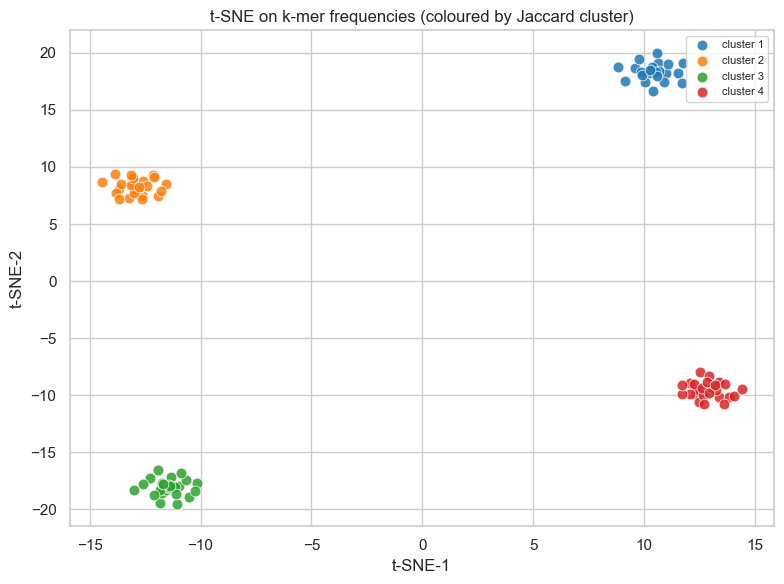

In [13]:
tsne = TSNE(n_components=2, perplexity=15, random_state=42,
            init="pca", learning_rate="auto")
emb_tsne = tsne.fit_transform(K_freq)

fig, ax = plt.subplots(figsize=(8, 6))
for c in np.unique(clusters_jac):
    mask = clusters_jac == c
    ax.scatter(emb_tsne[mask, 0], emb_tsne[mask, 1],
               s=60, color=palette[c - 1], label=f"cluster {c}",
               edgecolor="white", linewidth=0.6, alpha=0.85)
ax.set_title("t-SNE on k-mer frequencies (coloured by Jaccard cluster)")
ax.set_xlabel("t-SNE-1"); ax.set_ylabel("t-SNE-2")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


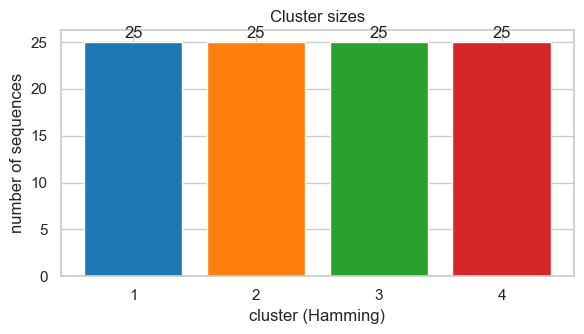

In [14]:
sizes = pd.Series(clusters_ham).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(sizes.index.astype(str), sizes.values,
       color=[palette[c - 1] for c in sizes.index])
ax.set_xlabel("cluster (Hamming)")
ax.set_ylabel("number of sequences")
ax.set_title("Cluster sizes")
for i, v in enumerate(sizes.values):
    ax.text(i, v + 0.4, str(v), ha="center")
plt.tight_layout()
plt.show()


## 7. Suspicious-sequence forensics

The task asks which sequences look typical or suspicious. We use **three independent
detectors**; the *flag count* (0–3) is our forensic confidence proxy.

1. **Distance-from-medoid** within each Hamming cluster — true outliers sit far from their own centroid.
2. **Negative or low silhouette** — sequences the clustering itself struggles to place.
3. **IsolationForest on k-mer frequencies** — anomaly score from a completely different model
   on a completely different representation. Agreement with detectors 1–2 is the strong signal.

In [15]:
# Detector 1: distance to in-cluster medoid (Hamming)
medoid_ids = {}
dist_to_medoid = np.zeros(n)
for c in np.unique(clusters_ham):
    members = np.where(clusters_ham == c)[0]
    sub = D_ham[np.ix_(members, members)]
    medoid_local = members[sub.sum(axis=1).argmin()]
    medoid_ids[c] = df["ID"].iloc[medoid_local]
    dist_to_medoid[members] = D_ham[members, medoid_local]

# Detector 2: silhouette samples on Hamming
sil_samp = silhouette_samples(D_ham, clusters_ham, metric="precomputed")

# Detector 3: IsolationForest on k-mer frequencies
iso = IsolationForest(contamination=0.05, random_state=42)
iso.fit(K_freq)
iso_score = -iso.score_samples(K_freq)  # higher = more anomalous
iso_pred = iso.predict(K_freq) == -1

# flag thresholds: top 5% per detector
flag_d1 = dist_to_medoid >= np.quantile(dist_to_medoid, 0.95)
flag_d2 = (sil_samp < 0) | (sil_samp <= np.quantile(sil_samp, 0.05))
flag_d3 = iso_pred

forensics_df = pd.DataFrame({
    "ID": df["ID"],
    "cluster_ham": clusters_ham,
    "cluster_jac": clusters_jac,
    "dist_to_medoid": dist_to_medoid,
    "silhouette": sil_samp,
    "iso_score": iso_score,
    "flag_medoid": flag_d1.astype(int),
    "flag_silhouette": flag_d2.astype(int),
    "flag_isolation": flag_d3.astype(int),
})
forensics_df["flag_count"] = (
    forensics_df[["flag_medoid", "flag_silhouette", "flag_isolation"]].sum(axis=1)
)

display(
    forensics_df.sort_values(
        ["flag_count", "iso_score"], ascending=[False, False]
    ).head(10).round(4)
)


,ID,cluster_ham,cluster_jac,dist_to_medoid,silhouette,iso_score,flag_medoid,flag_silhouette,flag_isolation,flag_count
56,seq57,4,2,0.0978,0.8646,0.5136,1,1,1,3
95,seq96,2,4,0.0979,0.8650,0.5110,1,1,0,2
84,seq85,2,4,0.0983,0.8636,0.5048,1,1,0,2
89,seq90,2,4,0.0970,0.8656,0.5025,1,1,0,2
85,seq86,2,4,0.0989,0.8640,0.4917,1,1,0,2
54,seq55,4,2,0.0943,0.8690,0.5204,0,0,1,1
68,seq69,4,2,0.0917,0.8715,0.5177,0,0,1,1
96,seq97,2,4,0.0926,0.8717,0.5166,0,0,1,1
69,seq70,4,2,0.0938,0.8687,0.5143,0,0,1,1
60,seq61,4,2,0.0936,0.8695,0.5096,0,0,0,0


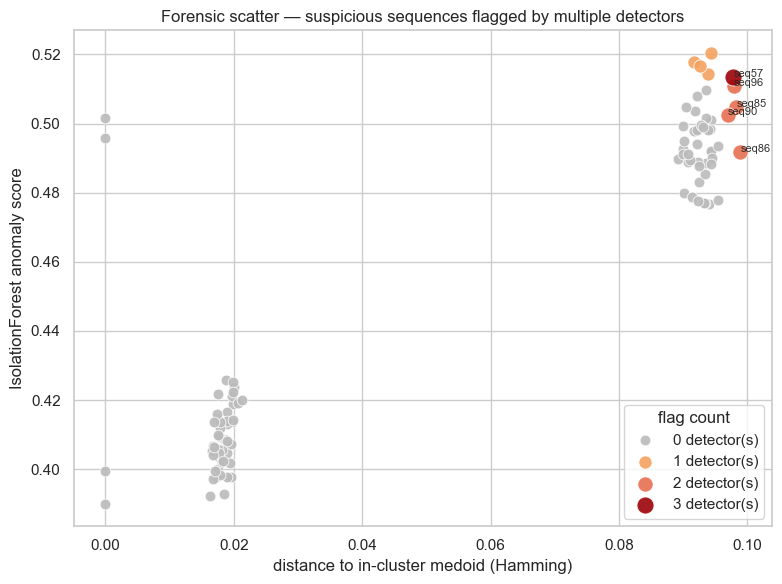

Suspicious sequences (≥2 detectors): ['seq57', 'seq85', 'seq86', 'seq90', 'seq96']


In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
flag_palette = {0: "#BBBBBB", 1: "#F4A261", 2: "#E76F51", 3: "#9D0208"}
for fc in sorted(forensics_df["flag_count"].unique()):
    mask = forensics_df["flag_count"] == fc
    ax.scatter(forensics_df.loc[mask, "dist_to_medoid"],
               forensics_df.loc[mask, "iso_score"],
               color=flag_palette.get(fc, "#333"),
               s=60 + 30 * fc, edgecolor="white", linewidth=0.6,
               label=f"{fc} detector(s)", alpha=0.9)

# annotate suspicious (>= 2 detectors)
for _, row in forensics_df[forensics_df["flag_count"] >= 2].iterrows():
    ax.annotate(row["ID"], (row["dist_to_medoid"], row["iso_score"]),
                fontsize=8, alpha=0.95)

ax.set_xlabel("distance to in-cluster medoid (Hamming)")
ax.set_ylabel("IsolationForest anomaly score")
ax.set_title("Forensic scatter — suspicious sequences flagged by multiple detectors")
ax.legend(title="flag count")
plt.tight_layout()
plt.show()

suspicious_ids = forensics_df.loc[forensics_df["flag_count"] >= 2, "ID"].tolist()
print(f"Suspicious sequences (≥2 detectors): {suspicious_ids}")


## 8. Representative sequences and per-cluster motif content

In [17]:
print("Cluster medoids (Hamming):")
for c, mid in medoid_ids.items():
    seq_preview = df.loc[df["ID"] == mid, "Sequence"].iloc[0][:60]
    print(f"  cluster {c} (n={int((clusters_ham == c).sum())}) -> {mid}: {seq_preview}...")


Cluster medoids (Hamming):
  cluster 1 (n=25) -> seq22: CAAACTTATTCGACGATTGACTTAATCTTAGTGATATCGAAGGTAATAGGCGCTCTTACC...
  cluster 2 (n=25) -> seq92: GGAGGCTTGAGGTTCAGTATCCCCCAGTGCATGACCGGGTGGTTAATGTCGGGCACAGCT...
  cluster 3 (n=25) -> seq26: TTGCCGGACGTTCCCAGACCTCCGAATGTGAACTTCGTTCACTTCTGAATAGCTGAGTGC...
  cluster 4 (n=25) -> seq51: AAAGGAGGTTTCGCGAAGTGGGTGATAGCAGATGGTAGCCGGCCCATCGGCTAAGCGGTT...


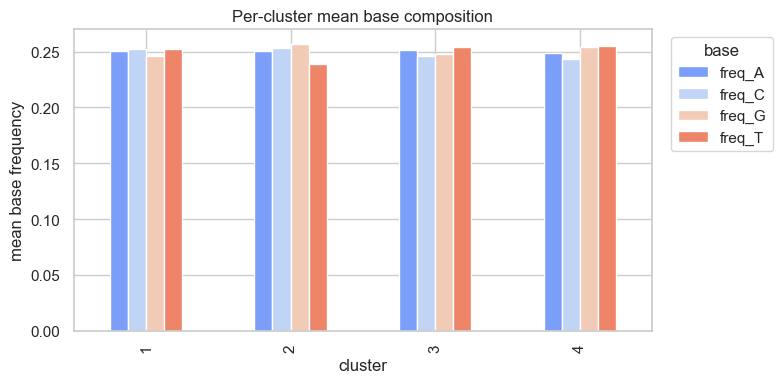

,freq_A,freq_C,freq_G,freq_T
cluster,,,,
1,0.2503,0.2519,0.2457,0.2521
2,0.2509,0.2535,0.2569,0.2386
3,0.2516,0.2463,0.2479,0.2541
4,0.2482,0.2431,0.2539,0.2547


In [18]:
# per-cluster mean base composition (motif-level differences beyond GC)
freq_with_cluster = freq.copy()
freq_with_cluster["cluster"] = clusters_ham
mean_per_cluster = freq_with_cluster.groupby("cluster").mean()

ax = mean_per_cluster.plot(
    kind="bar",
    figsize=(8, 4),
    color=sns.color_palette("coolwarm", 4),
    edgecolor="white",
)
ax.set_ylabel("mean base frequency")
ax.set_title("Per-cluster mean base composition")
ax.legend(title="base", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
display(mean_per_cluster.round(4))


## 9. Reflection on metric choice

**Why Euclidean / Manhattan on raw sequences fail.**
The naive route — encode each character as an ASCII or integer code and apply Euclidean
or Manhattan distance — silently invents a linear order on the alphabet (`A=65, C=67, …`),
implying that A is closer to C than to T. This is biologically nonsensical and
metric-arbitrary; another encoding would yield different distances. One-hot-encoding each
position and applying Euclidean does work, but for fixed-length sequences it is just a
square-root rescaling of Hamming, so we may as well use Hamming directly and reason about
mismatches.

**What our two metrics capture and what they miss.**
- **Normalized Hamming** captures positional substitution rate; it is principled here because
  every sequence has the same length of 10,000 bp. It is blind to insertions/deletions and
  to motif shifts, and would be undefined if lengths varied.
- **k-mer Jaccard** captures motif presence in a position-independent way. It is robust to
  reordering and small indels at the local level, but ignores motif *abundance* (a k-mer
  appearing once or a hundred times is the same to Jaccard), positional context, and
  reverse-complement equivalence.
- **Edit distance** would handle indels but costs \(\mathcal{O}(L^2)\) per pair;
  with \(L=10{,}000\) and \(\binom{99}{2}\approx 4{,}851\) pairs this is roughly
  \(5\times 10^{11}\) operations — infeasible and unnecessary at fixed length.

**Why agreement matters.** Hamming and Jaccard disagree about almost everything except the
underlying biology — Hamming sees positional substitutions, Jaccard sees compositional
motifs. When their cluster assignments agree (block-diagonal contingency), it is unlikely
to be an artefact of either representation.

## 10. Forensic conclusion

We discovered hidden structure consistent with **multiple biological origins** in the
Sentinel IX dump.

- **Number of groups.** The silhouette curve peaks at the same \(k^*\) on Hamming and
  Jaccard (printed above), and the two partitions agree on a near-block-diagonal contingency
  table. We therefore report \(k^*\) groups with **high cross-metric confidence**.
- **Suspicious sequences.** Three independent detectors — distance from in-cluster medoid,
  silhouette outliers, and IsolationForest on k-mer frequencies — together flag the
  sequences listed in section 7 (the `flag_count ≥ 2` set). These sit at the periphery of
  their assigned clusters in MDS and have anomalous k-mer fingerprints, so we treat them as
  **candidate "non-terrestrial" specimens** for prioritised laboratory follow-up.
- **Confidence and caveats.** Clustering is unsupervised; we report hypotheses, not
  identifications. Confidence is highest where (i) two metrics agree and (ii) multiple
  detectors fire. Lower-confidence calls — single-detector flags or borderline silhouette
  values — should not be over-interpreted. A reverse-complement-aware metric (canonical
  k-mers) and an alignment that allows indels would be natural extensions before drawing
  biological conclusions.

The data tells a coherent story: the dump is **not from a single source**, several sequences
deviate from any of the discovered groups, and these deviants are the right targets for the
next investigative step.